In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from alpha.analysist import datastore

In [3]:
ds = datastore.DataStore(live=False)

In [29]:
s = "2026-09-30"
e = "2026-09-30"
trades = ds.trades(start=s, end=e)

In [31]:
trades.df

,symbol,strategy_id,price,side
t,,,,
2026-09-30 10:28:01,005930,추세,273500.0,entry
2026-09-30 10:30:01,005930,추세,272500.0,exit


/app/src/alpha/analysist/plotter.py:743: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()          # 여러 축/제목/범례가 서로 겹치지 않도록 여백을 자동 조정
/app/src/alpha/analysist/plotter.py:743: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()          # 여러 축/제목/범례가 서로 겹치지 않도록 여백을 자동 조정
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


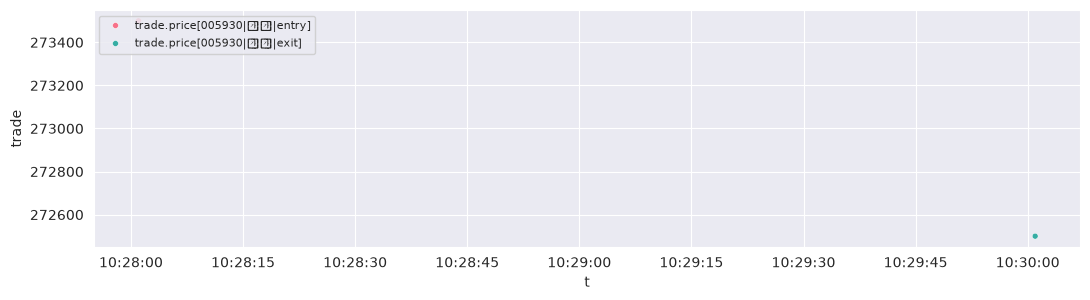

(<Figure size 1100x310 with 1 Axes>, [<Axes: xlabel='t', ylabel='trade'>])

In [32]:
trades.plot(columns=["price"], kind="mark")

In [34]:
tick = ds.ticks(symbol="005930", start=s, end=e)

/app/src/alpha/analysist/plotter.py:743: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()          # 여러 축/제목/범례가 서로 겹치지 않도록 여백을 자동 조정
/app/src/alpha/analysist/plotter.py:743: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()          # 여러 축/제목/범례가 서로 겹치지 않도록 여백을 자동 조정
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


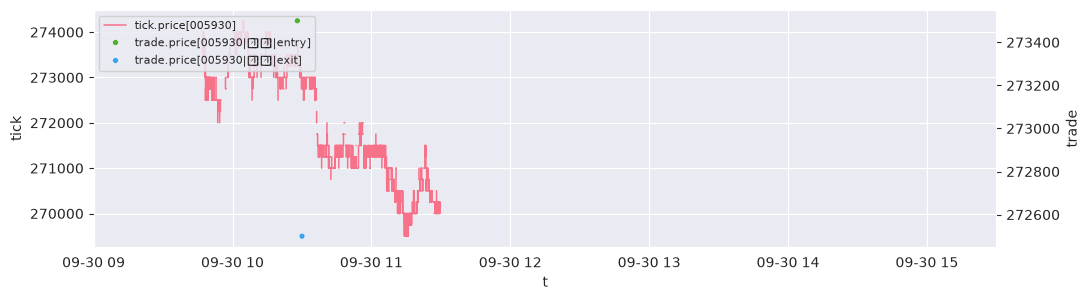

(<Figure size 1100x310 with 2 Axes>, [<Axes: xlabel='t', ylabel='tick'>])

In [36]:
tick.resample_frame("s").time_frame(mode="s",start=s + " 09:00:00", end=e + " 15:30:00").columns("price").add(trades).plot(kind={"trade":"mark"})

In [42]:
bar = ds.bars(symbol="005930", start=s, end=e)

In [43]:
bar.series()

['bar.open[005930|60]',
 'bar.high[005930|60]',
 'bar.low[005930|60]',
 'bar.close[005930|60]',
 'bar.volume[005930|60]']

In [44]:
bar.add(trades).series()

['bar.open[005930|60]',
 'bar.high[005930|60]',
 'bar.low[005930|60]',
 'bar.close[005930|60]',
 'bar.volume[005930|60]',
 'trade.price[005930|추세|entry]',
 'trade.price[005930|추세|exit]']

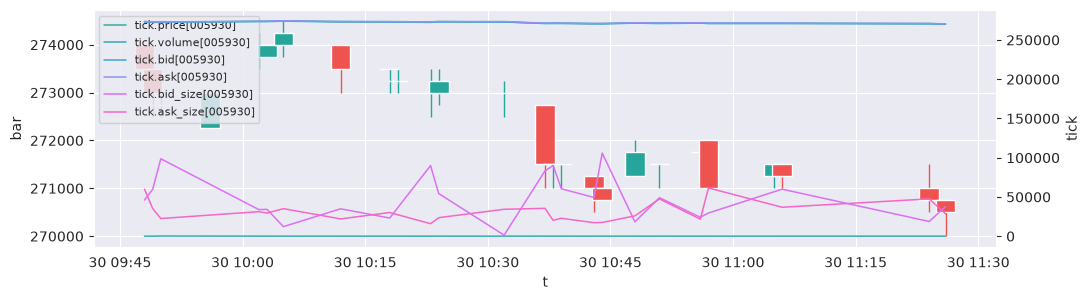

(<Figure size 1100x310 with 2 Axes>, [<Axes: xlabel='t', ylabel='bar'>])

In [47]:
bar.add(tick).plot(columns=[""], kind={"bar":"candle", "trade":"mark"})

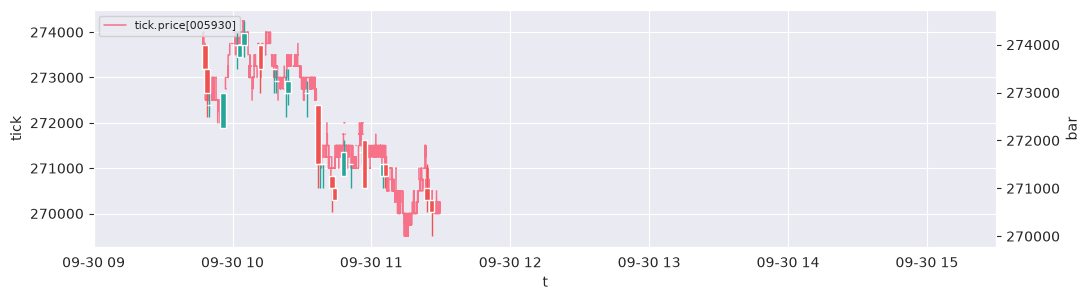

(<Figure size 1100x310 with 2 Axes>, [<Axes: xlabel='t', ylabel='tick'>])

In [48]:
tick.resample_frame("s").time_frame(mode="s",start=s + " 09:00:00", end=e + " 15:30:00").columns("price").add(bar).plot(kind={"bar":"candle"})